In [1]:
import sys
sys.path.append('/Users/paolamartire/shocks')
abspath = '/Users/paolamartire/shocks'
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
import Utilities.prelude as prel
import healpy as hp
import Utilities.operators as op

In [2]:
# Parameters
N = 4
coord_centre = np.array([1.0, 0.0, 0.0])  
vel_centre = np.array([-1, -0.2, 0.0])  
centre = (coord_centre, vel_centre)
speed = 3
times = np.arange(0, 10, 0.1)

Positive x: 96, Negative x: 96 after dt = 10.0


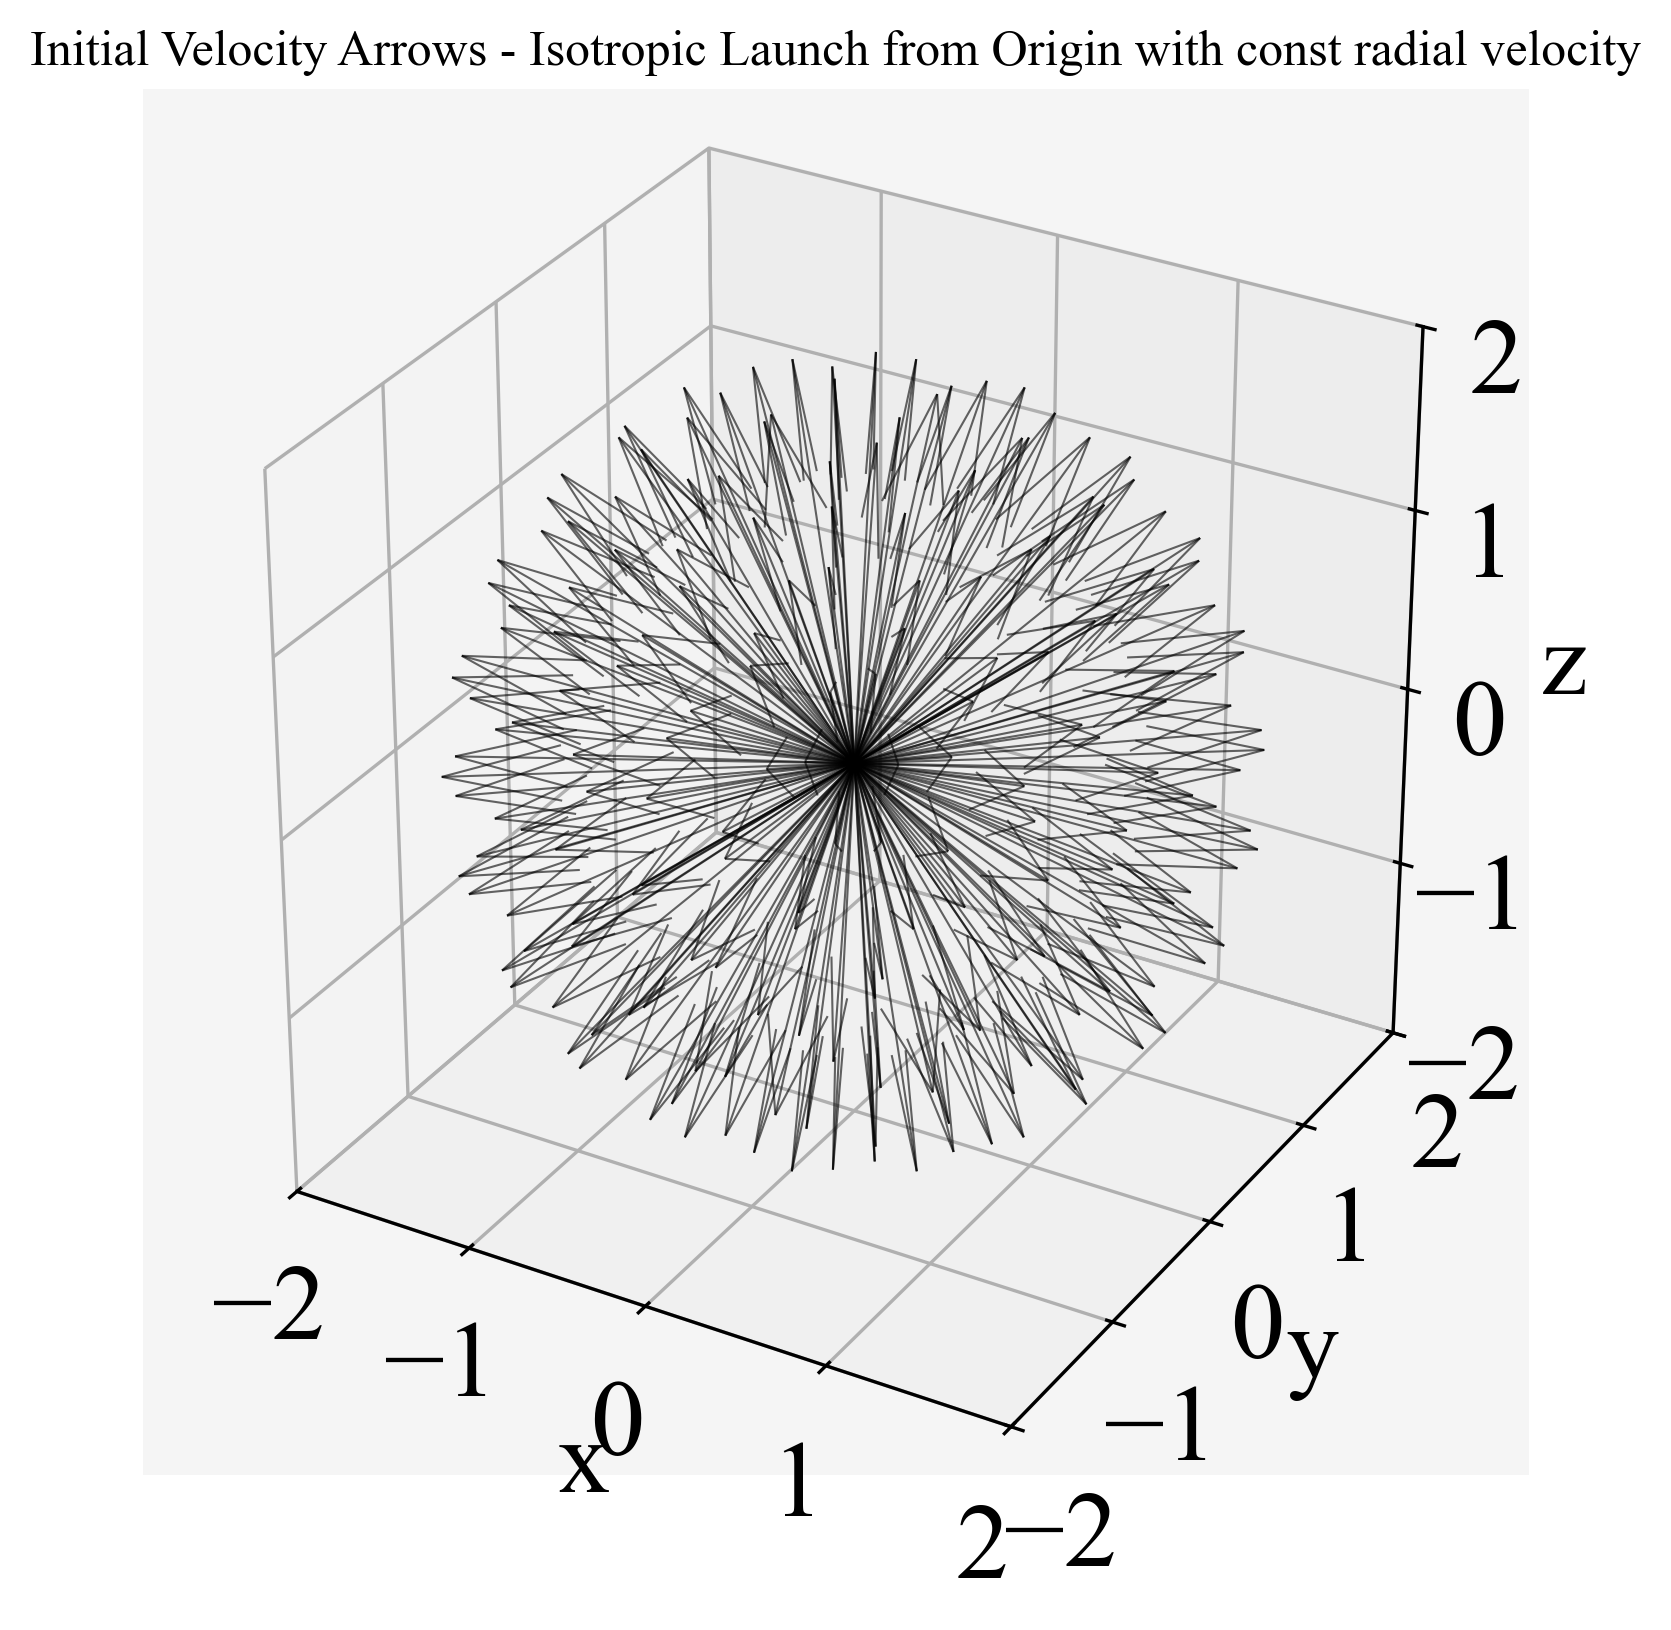

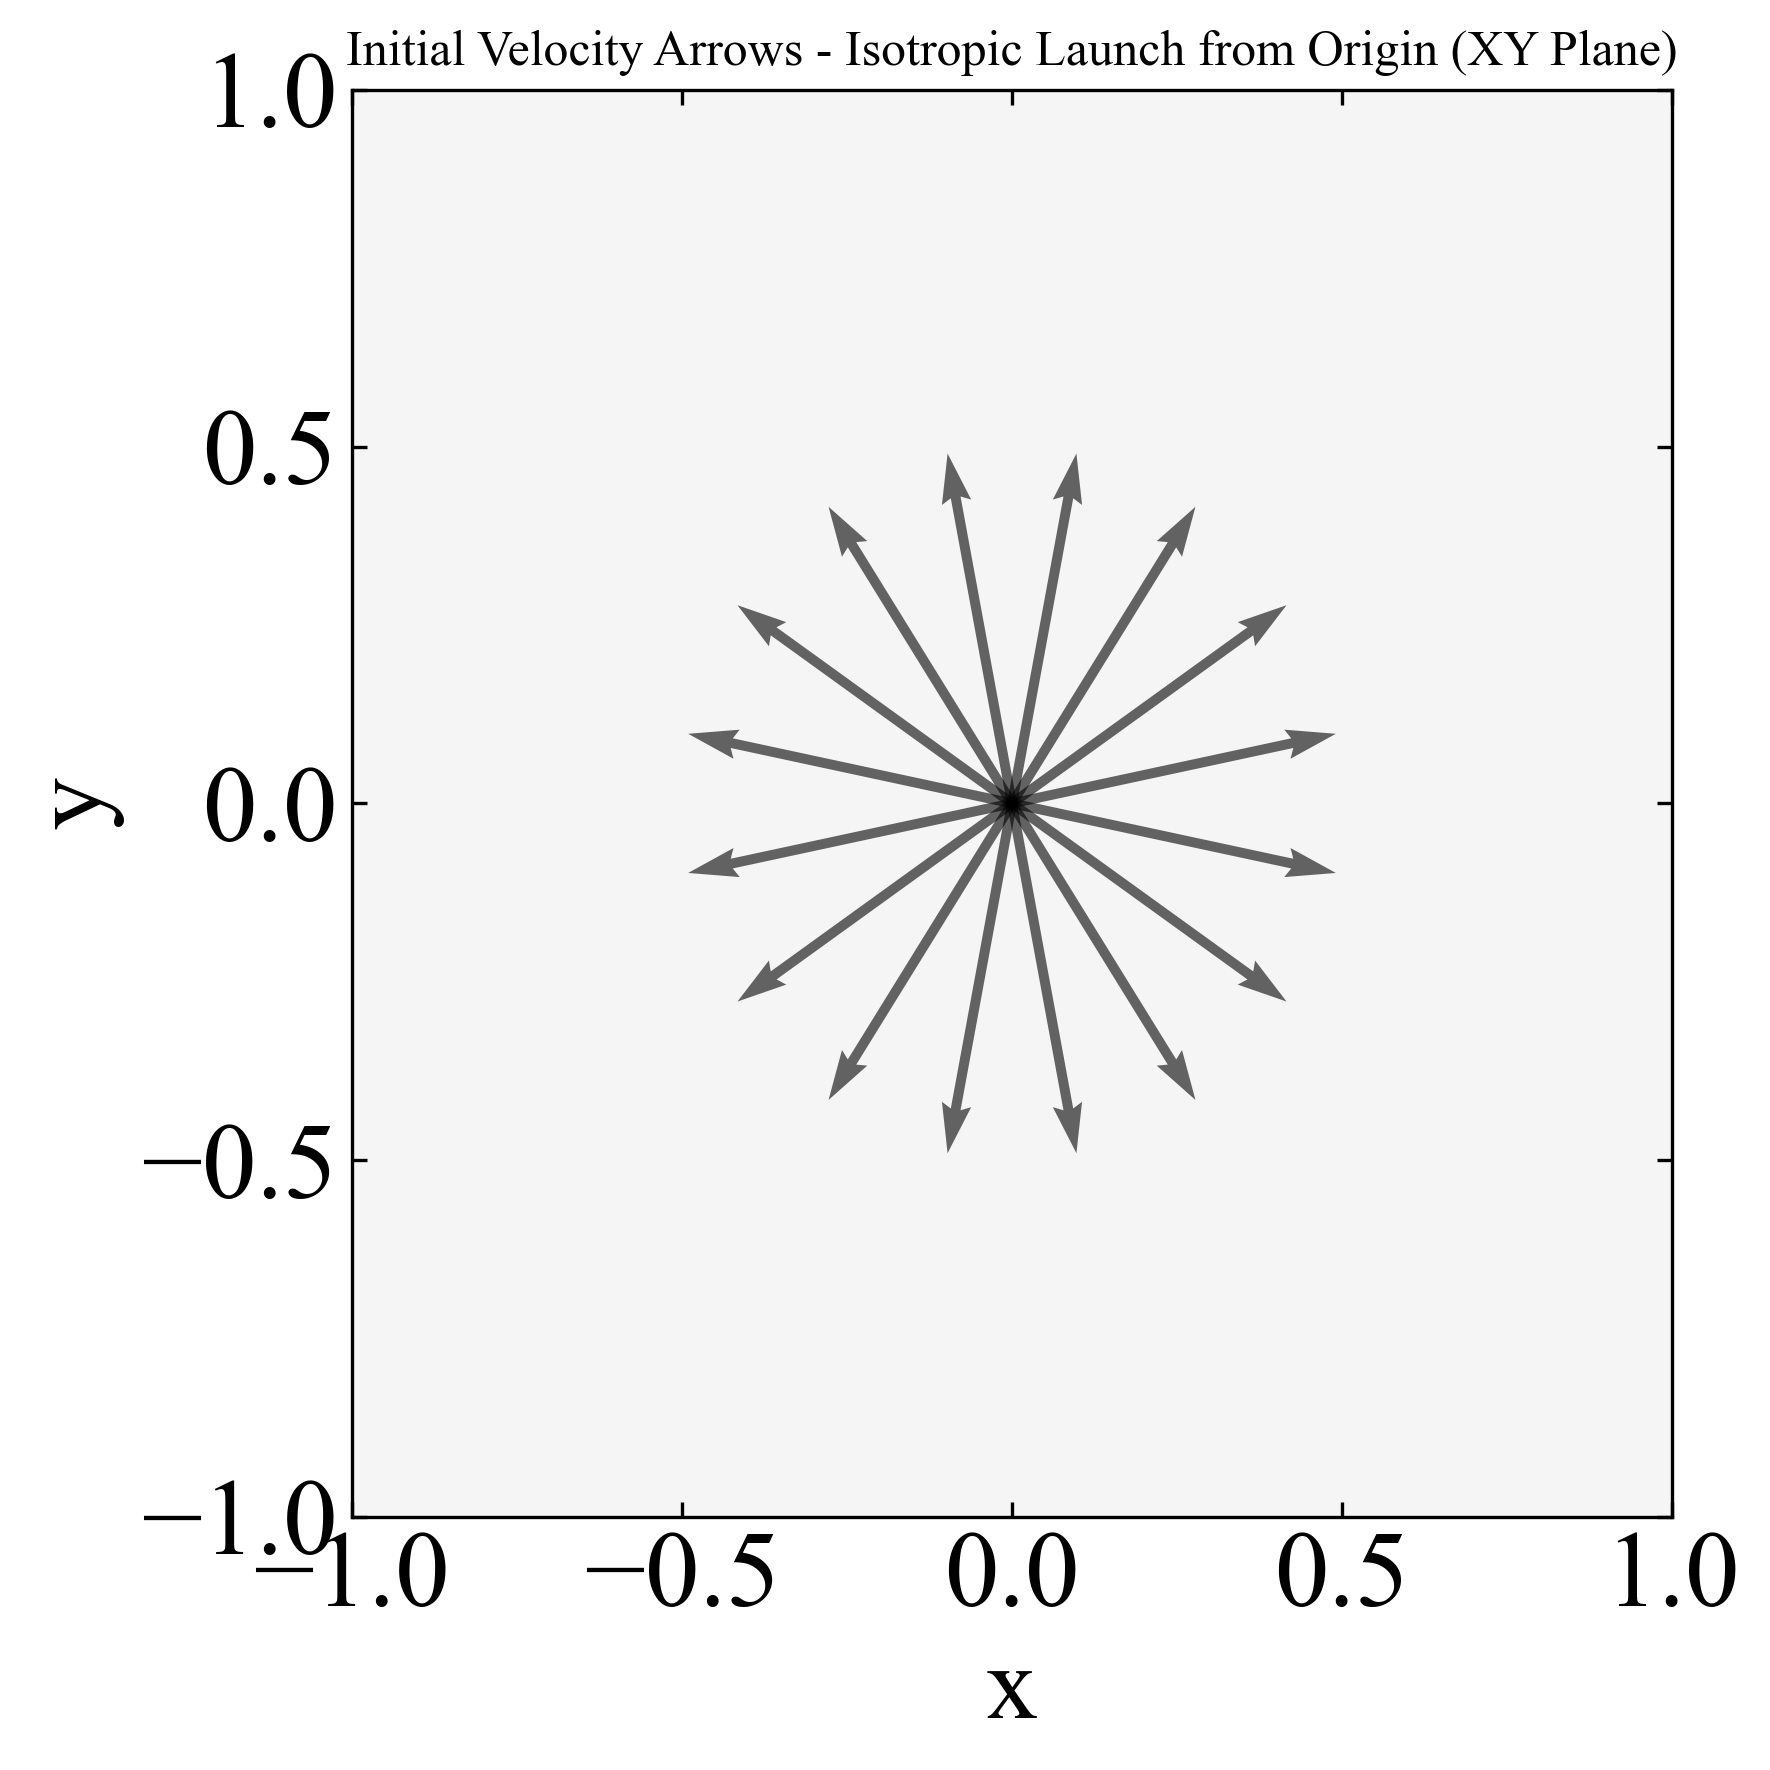

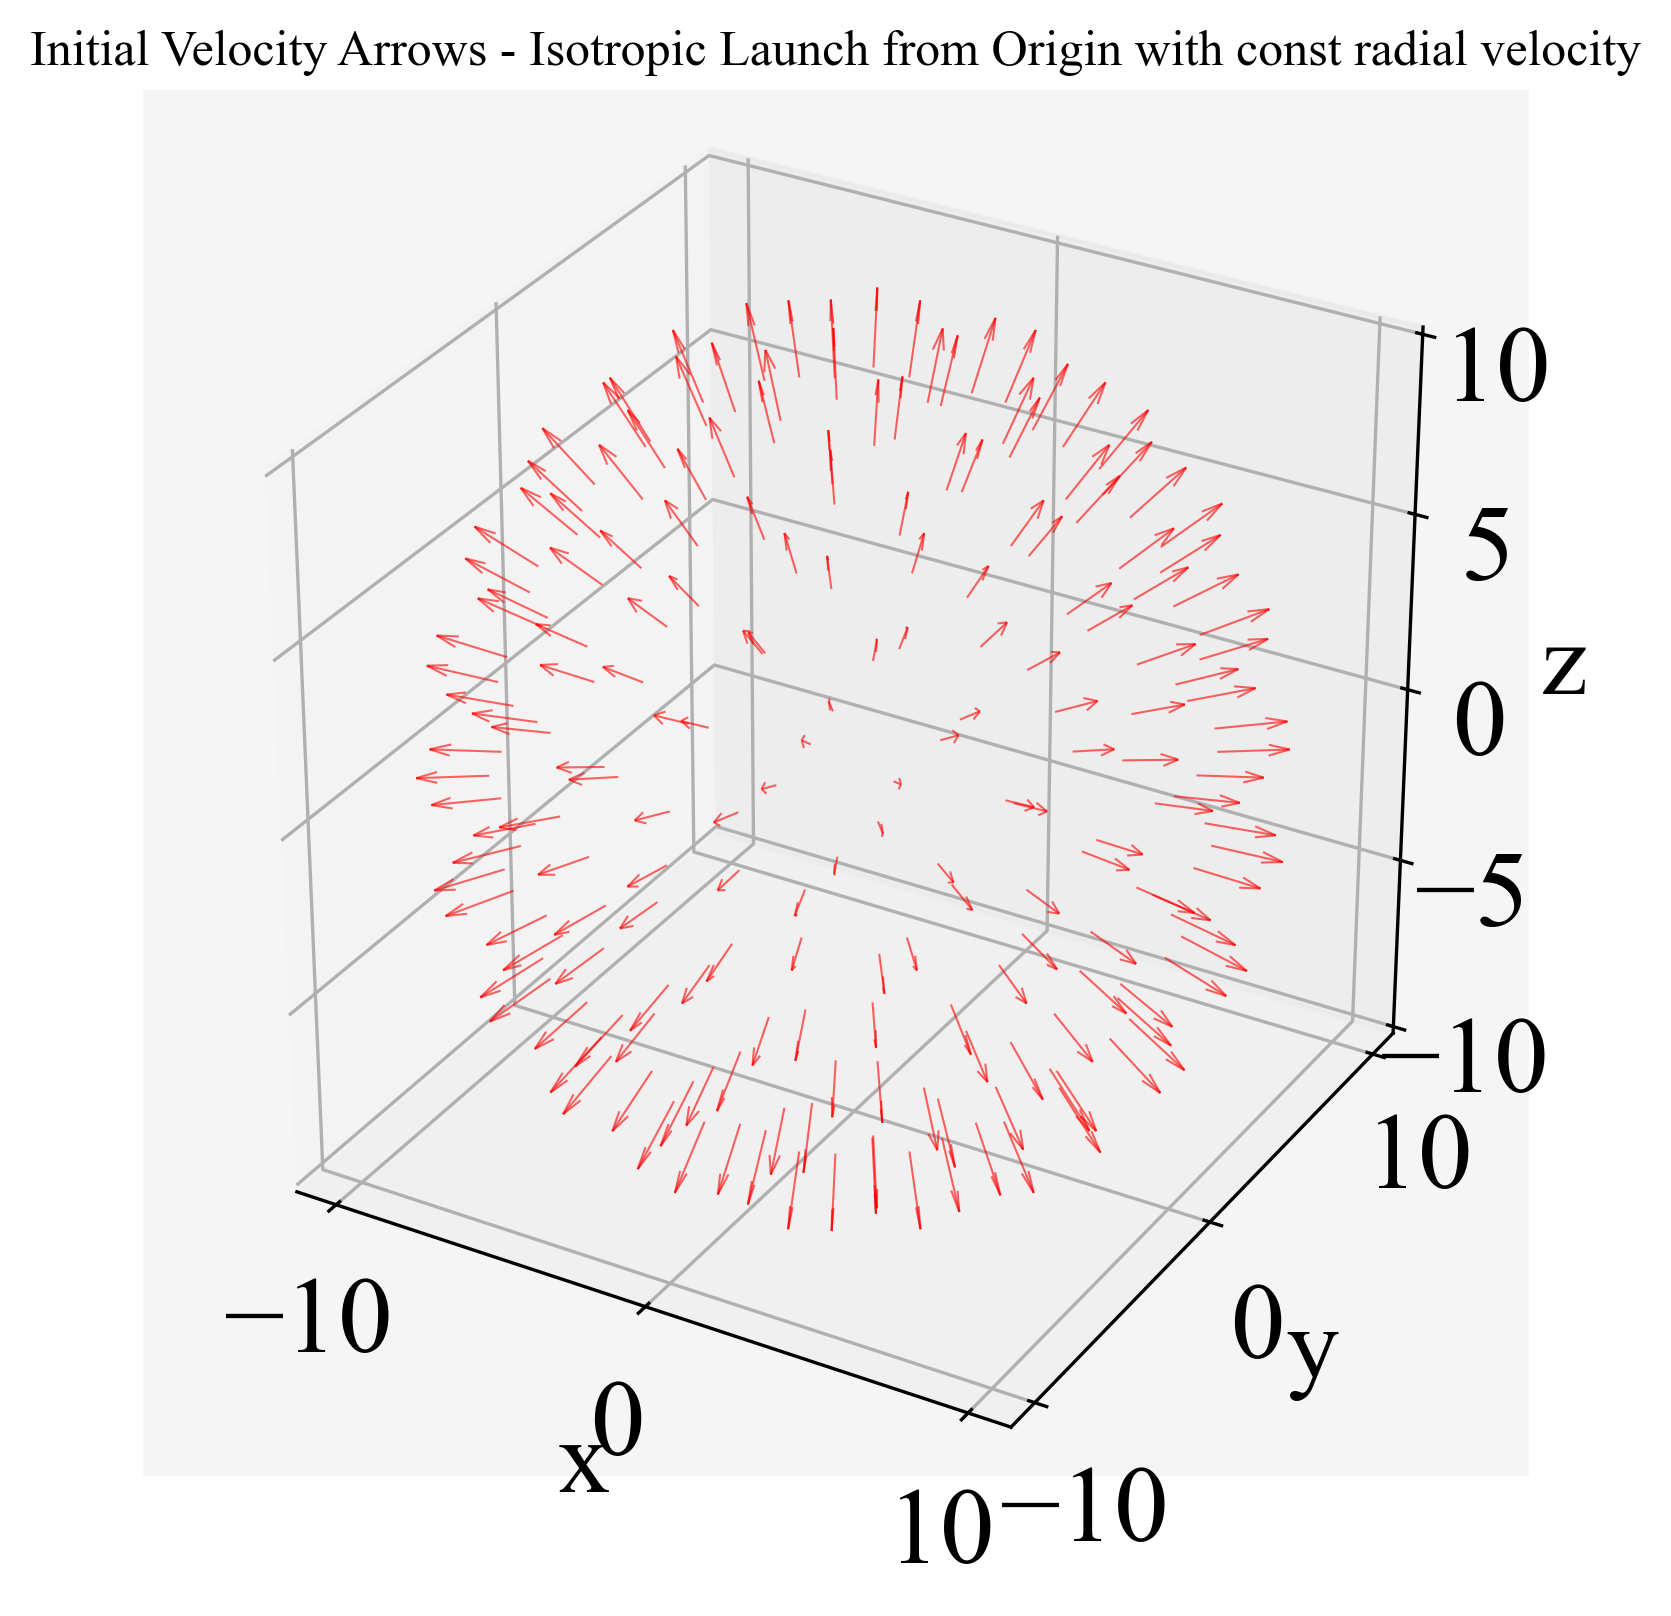

In [3]:
def launch_isotropic_particles_static(NSIDE, speed, dt):
    NPIX = hp.nside2npix(NSIDE)
    # create random isotropic directions for the launch and use them for your velocity
    observers_xyz = hp.pix2vec(NSIDE, range(NPIX))
    observers_xyz = np.array(observers_xyz)
    vx, vy, vz = observers_xyz[0], observers_xyz[1], observers_xyz[2]
    vx *= speed
    vy *= speed
    vz *= speed

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    scale = 2.0
    ax.quiver(0, 0, 0, vx, vy, vz, 
            length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'k')
    # Equal aspect ratio
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('Initial Velocity Arrows - Isotropic Launch from Origin with const radial velocity')
    max_range = scale * speed
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_zlim(-max_range, max_range)
    ax.set_box_aspect([1, 1, 1]) 

    fig = plt.figure(figsize=(6,6))
    plt.quiver(np.zeros_like(vx[vz==0]), np.zeros_like(vy[vz==0]), vx[vz==0], vy[vz==0],
            angles='xy', scale_units='xy', scale=2, alpha=0.6, linewidth=0.5, color = 'k')
    plt.xlim(-speed, speed)
    plt.ylim(-speed, speed)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Initial Velocity Arrows - Isotropic Launch from Origin (XY Plane)')
    plt.tight_layout()

    # Start at the origin and move ballistically for time dt
    x = vx * dt
    y = vy * dt
    z = vz * dt

    pos = np.column_stack((x, y, z))
    vel = np.column_stack((vx, vy, vz))
    return pos, vel


# Example
dt_single = 10.0
pos, vel = launch_isotropic_particles_static(N, speed=1.0, dt=dt_single)
xN, yN, zN = pos[:, 0], pos[:, 1], pos[:, 2]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
scale = 2.0
ax.quiver(xN, yN, zN, vel[:, 0], vel[:, 1], vel[:, 2], 
        length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'r')
# Equal aspect ratio
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Initial Velocity Arrows - Isotropic Launch from Origin with const radial velocity')
ax.set_box_aspect([1, 1, 1]) 

print(f'Positive x: {len(xN[xN>0])}, Negative x: {len(xN[xN<0])} after dt = {dt_single}')


Single launch at t=0 with speed: 3. Frame: centre, central point in [1. 0. 0.] with v = [-1.  -0.2  0. ]
After dt = 2, positive x: 96, negative x: 96


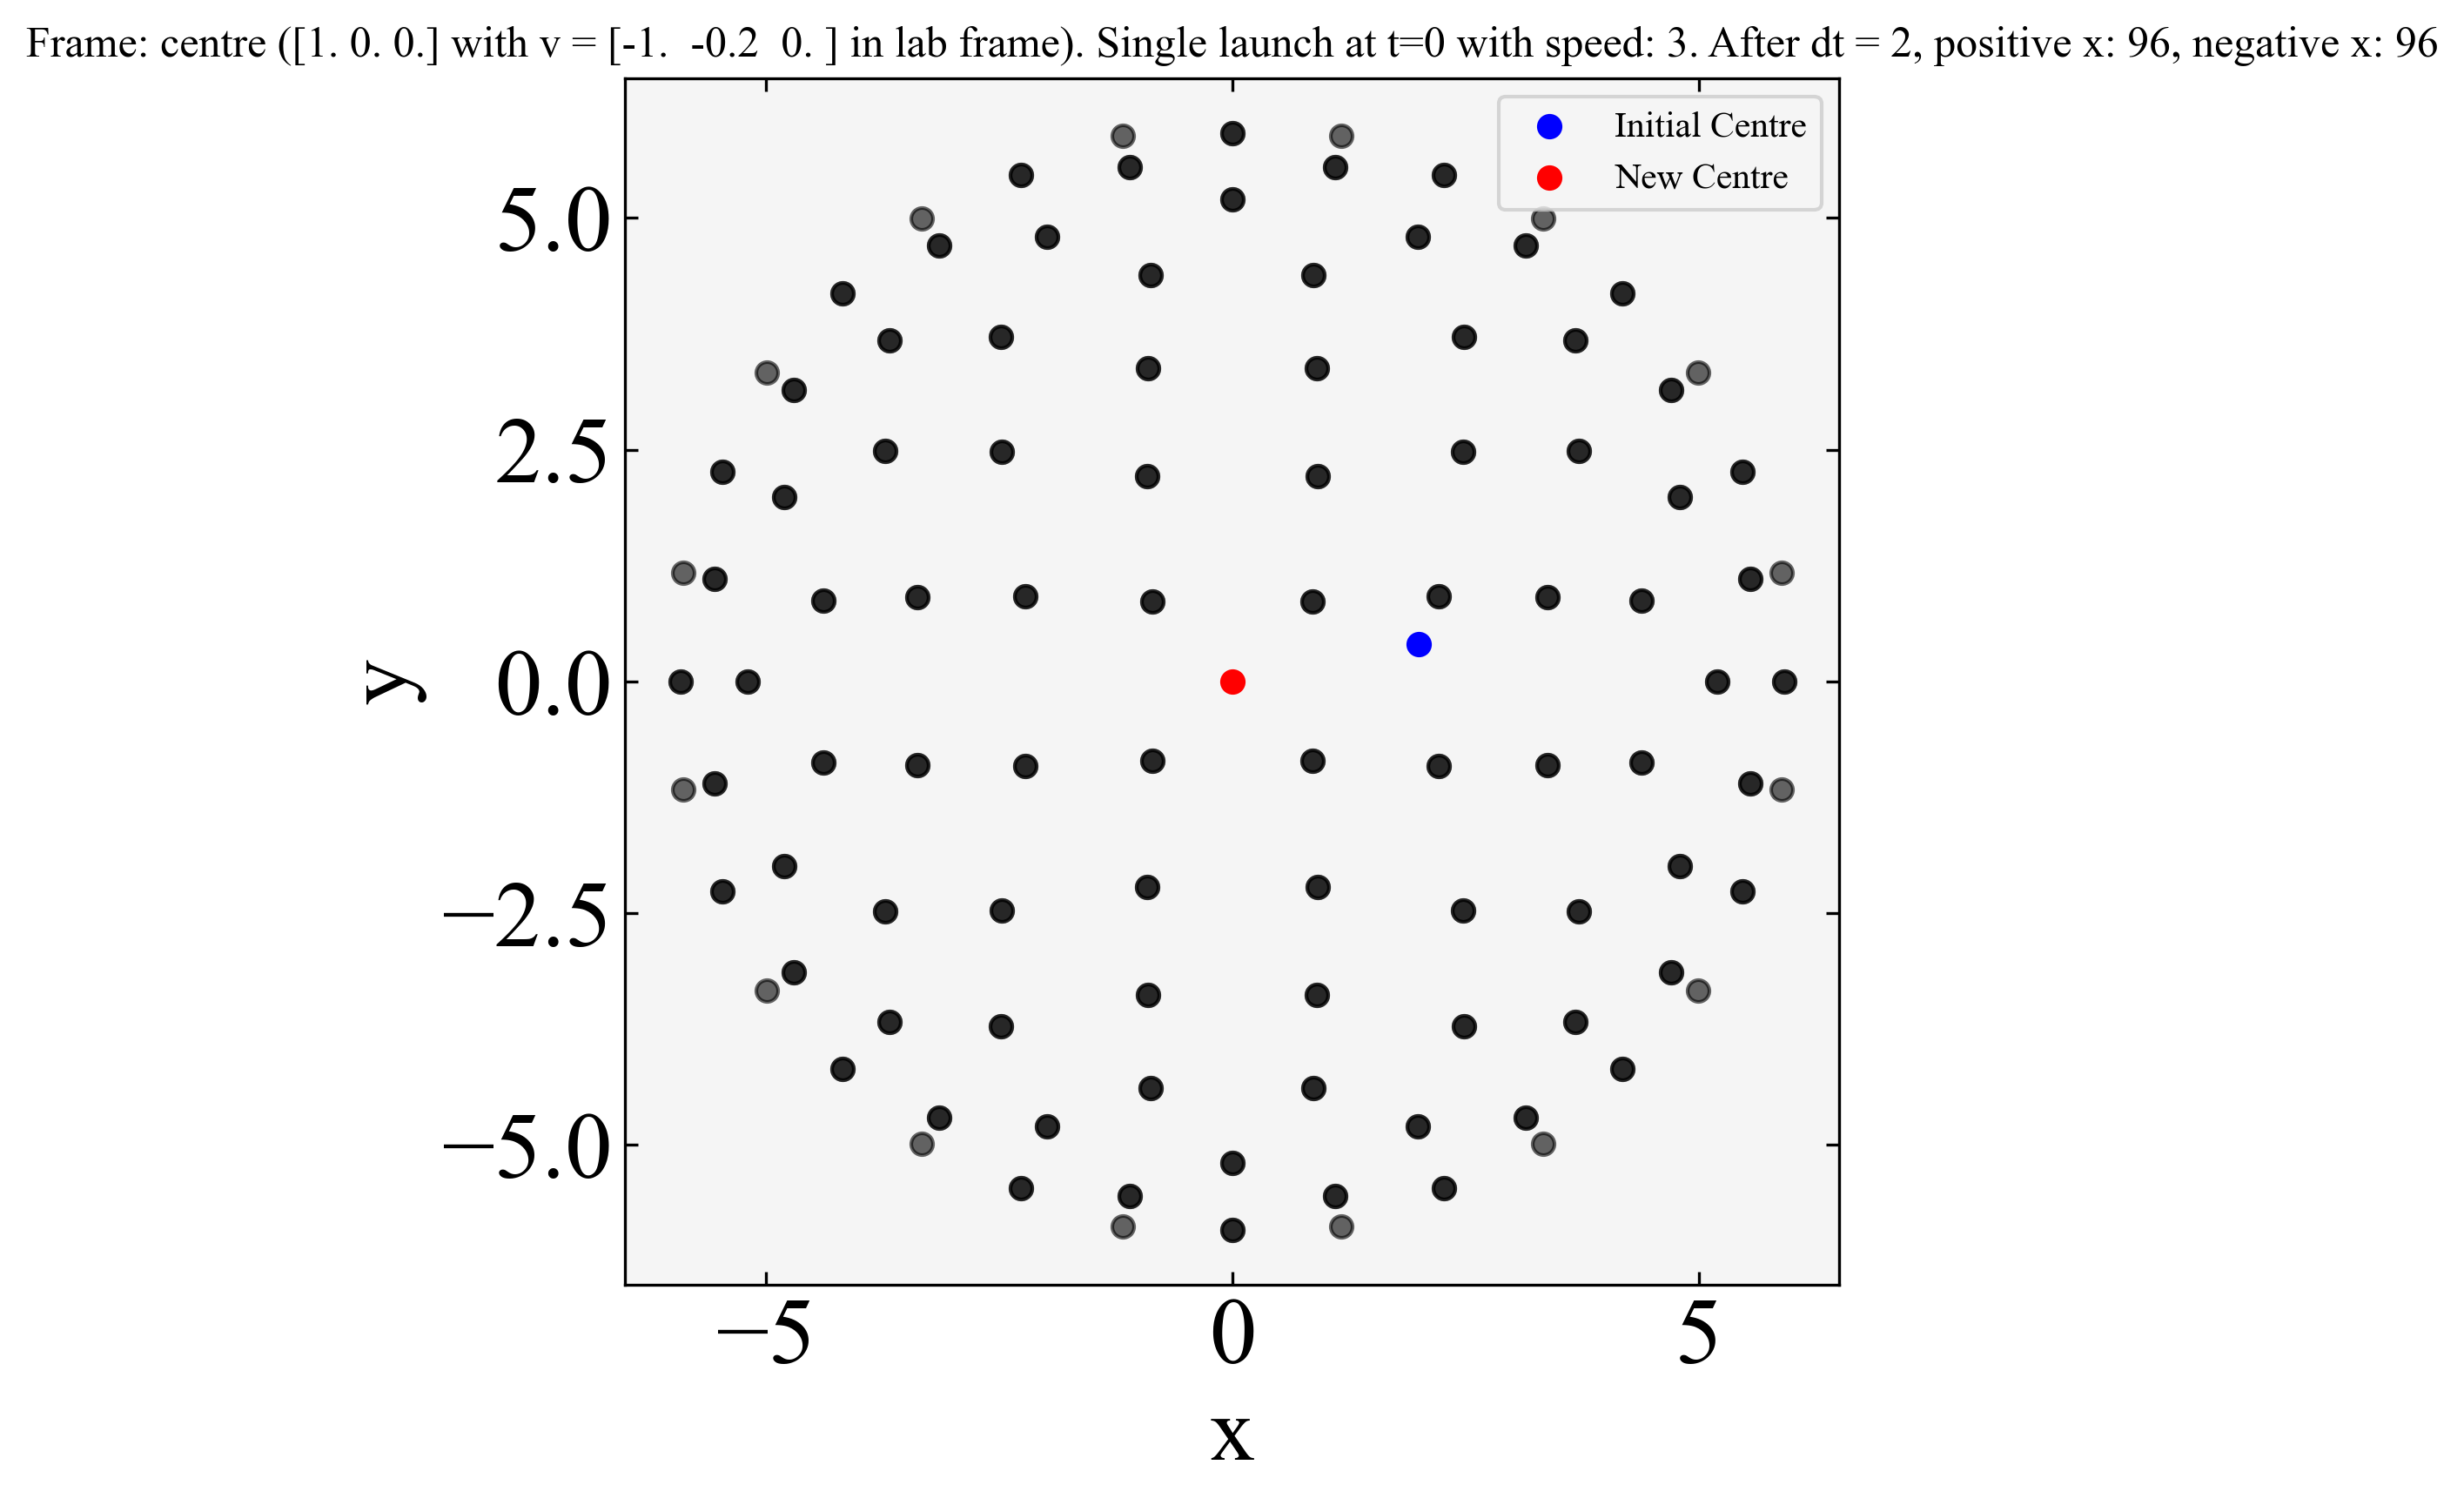

In [12]:
def launch_isotropic_particles_boost(NSIDE, speed, centre_i, dt, which_frame, visualize = False):
    """
    Gives:
    - position and velocities of isotropically launched particles from the chosen centre 
    - position and velocity of the centre with respect to the lab frame 
    after time dt
    """
    NPIX = hp.nside2npix(NSIDE)
    observers_xyz = hp.pix2vec(NSIDE, range(NPIX))
    observers_xyz = np.array(observers_xyz)
    if which_frame == 'lab' :
        coord_o_i, v_o_i = centre_i
    elif which_frame == 'centre': 
        coord_o_i = np.zeros(3)
        v_o_i = np.zeros(3)

    x_i = np.zeros(len(observers_xyz[0])) + coord_o_i[0]
    y_i = np.zeros(len(observers_xyz[1])) + coord_o_i[1]
    z_i = np.zeros(len(observers_xyz[2])) + coord_o_i[2]
    vx = speed * observers_xyz[0] + v_o_i[0]
    vy = speed * observers_xyz[1] + v_o_i[1]
    vz = speed * observers_xyz[2] + v_o_i[2]
   
    if visualize:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        scale = 2.0
        ax.quiver(x_i, y_i, z_i, vx, vy, vz, 
                length=2, normalize=False, alpha=0.6, linewidth=0.5, color = 'k')
        ax.scatter(coord_o_i[0], coord_o_i[1], coord_o_i[2], color='b', s=100)
        # Equal aspect ratio
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title(f'Initial Velocity Arrows - Isotropic Launch from {coord_o_i} in {which_frame} frame')
        max_range = scale * speed
        ax.set_xlim(-max_range, max_range)
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)
        ax.set_box_aspect([1, 1, 1]) 

        fig = plt.figure(figsize=(8, 8))
        plt.quiver(x_i[vz==0], y_i[vz==0], vx[vz==0], vy[vz==0],
                angles='xy', scale_units='xy', scale=2, alpha=0.6, linewidth=0.5, color = 'k')
        # it's your center
        plt.quiver(coord_o_i[0], coord_o_i[1], v_o_i[0], v_o_i[1], angles='xy', scale_units='xy', scale=2, linewidth=0.5, color = 'b')
        plt.xlim(-scale * speed, scale * speed)
        plt.ylim(-scale * speed, scale * speed)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Initial Velocity Arrows - Isotropic Launch from {coord_o_i} in {which_frame} frame (XY Plane)')
        plt.tight_layout()

    # Start at the origin and move ballistically for time dt
    x = x_i + vx * dt
    y = y_i + vy * dt
    z = z_i + vz * dt
    v_o = centre_i[1]
    coord_o = centre_i[0] + v_o * dt

    pos = np.column_stack((x, y, z))
    vel = np.column_stack((vx, vy, vz))

    if visualize:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        scale = 2.0
        ax.quiver(x, y, z, vx, vy, vz, 
                length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'k')
        if which_frame == 'lab':
            ax.scatter(centre_i[0][0]-coord_o[0], centre_i[0][1]-coord_o[1], centre_i[0][2]-coord_o[2], color='b', s=100, label='Initial Centre')
            # the new centre is 0
            ax.scatter(0, 0, 0, color='r', s=100, label='New Centre')
        else:
            ax.scatter(coord_o_i[0]-coord_o[0], coord_o_i[1]-coord_o[1], coord_o_i[2]-coord_o[2], color='b', s=100, label='Initial Centre')
            ax.scatter(0, 0, 0, color='r', s=100, label='New Centre')
        ax.legend()
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        # ax.set_xlim(-max_range, max_range)
        # ax.set_ylim(-max_range, max_range)
        # ax.set_zlim(-max_range, max_range)
        ax.set_title(f'Frame: {which_frame}, after dt = {dt}, positive x: {len(xN[xN>0])}, negative x: {len(xN[xN<0])}')
        ax.set_box_aspect([1, 1, 1]) 

    return pos, vel, coord_o, v_o

which_frame = 'centre'  # 'lab' or 'centre'
single_time = 2

pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=single_time, which_frame = which_frame, visualize=False) 
xN = pos[:, 0]
# the launch is at t=0. You want to know Npos and Nneg with resepct to the new orgin in case of "centre" 
# Npos= len(xN[xN > 0]) if which_frame == 'lab' else len(xN[xN > centre[1][0] * single_time]) 
# Nneg= len(xN[xN < 0]) if which_frame == 'lab' else len(xN[xN < centre[1][0] * single_time])
Npos= len(xN[xN > 0]) 
Nneg= len(xN[xN < 0]) 
plt.figure(figsize=(6,6))
plt.scatter(pos[:, 0], pos[:, 1], alpha=0.6, color='k')
if which_frame == 'centre':
    plt.scatter(centre[0][0]-coord_o[0], centre[0][1]-coord_o[1], color='b', label='Initial Centre')
    plt.scatter(0, 0, color='r', label='New Centre')
else:
    plt.scatter(centre[0][0], centre[0][1], color='b', label='Initial Centre')
    plt.scatter(coord_o[0], coord_o[1], color='r', label='New Centre')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Frame: {which_frame} ({centre[0]} with v = {centre[1]} in lab frame). Single launch at t=0 with speed: {speed}. After dt = {single_time}, positive x: {Npos}, negative x: {Nneg}')

print(f'Single launch at t=0 with speed: {speed}. Frame: {which_frame}, central point in {centre[0]} with v = {centre[1]}')
print(f'After dt = {single_time}, positive x: {Npos}, negative x: {Nneg}')

In [ ]:
which_frame = 'lab'  # 'lab' or 'centre'
# vel_centre = np.array([-0.2, -0.2, 0.0])  
# vel_centre = np.array([-1, -0.2, 0.0])  
# centre = (coord_centre, vel_centre)

Npos = np.zeros(len(times))
Nneg = np.zeros(len(times))
for i, time in enumerate(times):
    pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=time, which_frame = which_frame, visualize=False)
    xN = pos[:, 0]
    Npos[i] = len(xN[xN > 0])
    Nneg[i] = len(xN[xN < 0]) 

plt.figure(figsize=(6,6))
plt.plot(times, Npos, label='Positive x',  color='g')
plt.plot(times, Nneg, label='Negative x', color='r', linestyle='--')
if which_frame == 'lab':
    time_first_cross = centre[0][0]/(np.abs(centre[1][0])+speed) # time at which the first particle crosses x=0, which is the one with speed directed completely in -x
    time_o_cross = centre[0][0]/np.abs(centre[1][0])  # time at which the centre crosses x=0
    plt.axvline(time_o_cross, color='k', linestyle=':', label=f'Crossing time of centre at x=0')
    plt.axvline(time_first_cross, color='m', linestyle=':', label=f'First crossing time of centre at x=0 by particles')
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.legend()
plt.title(f'Frame: {which_frame}')

print(Npos[-1])

In [ ]:
which_frame = 'lab'  # 'lab' or 'centre'
single_time = 10
rmin = 0
rmax = 1.5 * speed * single_time 
bins_r = 0.5 * single_time * min(speed, np.linalg.norm(centre[1]))
r_bins = np.arange(rmin, rmax, bins_r)

pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=single_time, which_frame = which_frame, visualize=False) #True if i == 10 else False)

# if which_frame == 'lab':
#     pos_new = pos
# elif which_frame == 'centre':
#     new_centre = np.zeros(3) #centre[1] * single_time # with resepct to the old origin, i.e. where there was the lauch, so you can compare with pos
#     pos_new = pos - new_centre

xN = pos[:, 0]
r_all = np.linalg.norm(pos, axis=1)
# finding r for the particles launched in the x direction
if which_frame == 'lab': # the 1+ come from healpix
    r_inner = 1 + np.abs(centre[0][0]+(-speed+centre[1][0]) * single_time)
    r_outer = 1 + np.abs(centre[0][0]+(speed+centre[1][0]) * single_time)
else:
    r_inner = speed * single_time 
    r_outer = r_inner 
v_r, _, _ = op.to_spherical_components(vel[:,0], vel[:,1], vel[:,2], pos[:,0], pos[:,1], pos[:,2])

Rpos= r_all[xN > 0] 
Rneg= r_all[xN < 0] 

binRpos, r_bins = np.histogram(Rpos, bins=r_bins)
binRneg, r_bins = np.histogram(Rneg, bins=r_bins)

plt.figure(figsize=(6,6))
plt.scatter(r_bins[:-1], binRpos, s = 70, label='Positive x', color='r')
plt.scatter(r_bins[:-1], binRneg, s = 40, label='Negative x', color='b')
plt.axvline(r_inner, color='b', linestyle='--', label='Expected r for most negative x-launched ')
plt.axvline(r_outer, color='r', linestyle='--', label='Expected r for most positive x-launched ')
plt.xlabel('r')
plt.ylabel('Count')
plt.title(f'Frame: {which_frame}, after dt = {single_time}')
plt.legend()

In [ ]:
which_frame = 'centre'  # 'lab' or 'centre'
centre_updated = centre  # Initialize the centre for the first iteration
x_centre = np.zeros(len(times))
xN = []
plt.figure(figsize=(8, 6))
for i, time in enumerate(times):
    x_centre[i] = centre_updated[0][0]
    # the firsts are the one who are launched at the initial point and then will expand for all the time. I do some tricks instead of evolving them for all the times
    # To know if they are positive, you have to check their x with respect of the one of the center at each time
    dt = times[-1]-time
    pos, vel, _, _ = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre_updated, dt=dt, which_frame = which_frame, visualize=False) #True if i == 10 else False)
    centre_updated = (centre[0] + time * centre[1], centre[1]) 
    xN.append(pos[:, 0])

Npos = np.zeros(len(times))
Nneg = np.zeros(len(times))
for i, time in enumerate(times):
    for j in range(i):
        Npos[i] += len(xN[i] > x_centre[i])
        Nneg[i] += len(xN[i] < x_centre[i])

plt.figure(figsize=(8, 6))
plt.scatter(times, Npos, label='Positive x', marker='o', s = 15)
plt.scatter(times, Nneg, label='Negative x', marker='o', s = 4)
# plt.axvline(dt_O_for_centre, color='k', linestyle='--', label=f'Centre crosses x=0')
# for k, dt_cross in enumerate(crossing_t):
#     plt.axvline(dt_cross, color='g', linestyle='--', label=f'Crossing' if k == 0 else "")
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.title(f'Continuous launch each {np.diff(times)[0]} with speed: {speed}. Frame: {which_frame}, central point in {centre[0]} with v = {centre[1]}')
plt.grid()
# plt.yscale('log')
plt.legend()



In [ ]:
which_frame = 'centre'  # 'lab' or 'centre'
v_o_r, _, _ = op.to_spherical_components(vel_centre[0], vel_centre[1], vel_centre[2], coord_centre[0], coord_centre[1], coord_centre[2])
x_all = []
r_all = []
vr_all = []
centre_updated = centre  
for dt in dts:
    # if dt == dts[1]:
    #     pos, vel = launch_isotropic_particles_boost(N, speed=speed, v_o = v_i, dt=dt, which_frame = which_frame, visualize = True)
    # else:
    pos, vel, coord_o, v_o_i = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre_updated, dt=dt, which_frame = which_frame, visualize = False)
    x_all.append(pos[:,0])
    r_all.append(np.linalg.norm(pos, axis=1))
    v_r, _, _ = op.to_spherical_components(vel[:,0], vel[:,1], vel[:,2], pos[:,0], pos[:,1], pos[:,2])
    vr_all.append(v_r)
    centre_updated = (coord_o, v_o_i)

xN = np.concatenate(x_all)
rN = np.concatenate(r_all)
vrN = np.concatenate(vr_all)

rmin = 0
rmax = 1.5 * np.max(rN)
bins_r = 4 #1.2 * np.min(np.abs(vrN) / np.min(np.diff(dts)))
r_bins = np.arange(rmin, rmax, bins_r)
dN_dtpos = np.zeros(len(r_bins)-1) 
dN_dtneg = np.zeros(len(r_bins)-1)
# Compute the number of particles in each radial bin for positive and negative x
for j in range(len(dN_dtneg)):
    in_bin = (rN >= r_bins[j]) & (rN < r_bins[j+1]) & (vrN > 0)
    dN_dtpos[j] = len(xN[in_bin & (xN > 0)]) * np.mean(vrN[in_bin & (xN > 0)])  if len(xN[in_bin & (xN > 0)]) > 0 else 0  # Weight by average radial velocity
    dN_dtneg[j] = len(xN[in_bin & (xN < 0)]) * np.mean(vrN[in_bin & (xN < 0)])  if len(xN[in_bin & (xN < 0)]) > 0 else 0  # Weight by average radial velocity

plt.figure(figsize=(8, 6))
plt.scatter(r_bins[:-1], dN_dtpos, label='Positive x', s = 15)
plt.scatter(r_bins[:-1], dN_dtneg, label='Negative x', s = 10)
plt.xlabel('Radial Distance')
plt.ylabel(r'dN/dt $v_{\rm r}$')
plt.title(f'Continuous launch, Frame: {which_frame} after dt={dt:.1f}, speed: {speed}, v_o: {centre[1]}')
plt.grid()
# plt.yscale('log')
plt.legend()